In [1]:
import os
import openmc
import numpy as np
from IPython.display import Image, display
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm , Normalize
from sklearn.metrics import r2_score
from datetime import datetime


In [2]:
# pulizia per sicurezza

os.system("rm *.h5")
os.system("rm *.xml")
os.system("rm *.out")
os.system("rm *.png")

rm: cannot remove '*.out': No such file or directory


0

VARIABILI IMPORTANTI

In [3]:
def load_parameters(filename='parametri.txt'):
    """
    Legge i parametri dal file txt e li restituisce come un dizionario.
    """
    params = {}
    # Forniamo np al contesto di esecuzione per gestire np.sqrt()
    context = {'np': np} 
    
    with open(filename, 'r') as f:
        code = f.read()
        exec(code, context, params)
    
    # Rimuoviamo 'np' e altri built-in dal dizionario finale
    return {k: v for k, v in params.items() if not k.startswith('__') and k != 'np'}

p = load_parameters('../parametri.txt')


# --- Parametri Geometrici ---
R_CORE    = p['R_CORE']
REF_SIDE  = p['REF_SIDE']
REF_BOT   = p['REF_BOT']
H_CORE    = p['H_CORE']

# --- Parametri Logici ---
R_PIPE    = p['R_PIPE']

# --- Parametri Pin/Lattice ---
R_FUEL    = p['R_FUEL']
CLAD_THICK= p['CLAD_THICK']
R_WATER_THICK = p['R_WATER_THICK']
R_PIN     = p['R_PIN']
PITCH     = p['PITCH']

# --- Parametri Target ---
R_TARGET  = p['R_TARGET']
H_TARGET  = p['H_TARGET']
P_TARGET  = p['P_TARGET']

# --- Sorgente e Simulazione ---
S             = p['S']
photon_energy = p['photon_energy']
bin_ris       = p['bin_ris']
batches       = p['batches']
particles     = p['particles']
inactive      = p['inactive']
arricchimento = p['arricchimento']

MATERIALI

In [4]:
fuel = openmc.Material(name='fuel')
fuel.add_nuclide('U235', arricchimento)
fuel.add_nuclide('U238', 1.0 - arricchimento)
fuel.add_nuclide('O16', 2.0)
fuel.set_density('g/cm3', 10.96)

# materiale di rivestimento
cladding = openmc.Material (name = 'cladding')
cladding.add_element('Zr', 1.0) 
cladding.set_density('g/cm3', 6.49)

# materiale di moderatore
water = openmc.Material (name = 'water')
water.add_element('H', 2.0)
water.add_element('O', 1.0)
water.set_density('g/cm3', 1.10)
water.add_s_alpha_beta('c_D_in_D2O') # aggiungo la tabella di scattering termico
# n.b.  le sezioni d'urto veloci sono già incluse di default

# aggiungo unriflettore in ACCIAIO INOX
# Usiamo SS316 che è standard, denso e riflette senza moderare troppo
reflector = openmc.Material(name='reflector')
reflector.add_element('Fe', 0.65)
reflector.add_element('Cr', 0.17)
reflector.add_element('Ni', 0.12)
reflector.add_element('Mo', 0.02)
reflector.add_element('Mn', 0.02)
reflector.set_density('g/cm3', 7.9) # Densità alta per riflettere bene

# voglio una sorgente puntiforme di neutroni in un punto specifico
marker_mat = openmc.Material(name='marker')
marker_mat.set_density('g/cm3', 1e-10) # Densità quasi nulla per non disturbare la fisica
marker_mat.add_nuclide('He4', 1.0) # elio, non interagisce praticamente

# Carburo di Boro B4C per le barre di controllo
control_rod = openmc.Material(name='B4C')
control_rod.add_element('B', 4.0)
control_rod.add_element('C', 1.0)
control_rod.set_density('g/cm3', 2.52) # Densità teorica B4C

mat_target = fuel # dal paper di lorenzo si nota un otttimo per U2O

materials = openmc.Materials([fuel, cladding, water, reflector, marker_mat, control_rod, mat_target])
materials.export_to_xml()


GEOMETRIA

In [5]:
# --- 0. PIANI Z (ASSOLUTI) ---
z_bot_ref = openmc.ZPlane(z0=-REF_BOT, boundary_type='vacuum')
z_bot_core = openmc.ZPlane(z0=0.0)
z_top_core = openmc.ZPlane(z0=H_CORE)
z_top_world = openmc.ZPlane(z0=H_CORE + 5.0, boundary_type='vacuum')

# Piani Z Target
z_mid = H_CORE - P_TARGET
z_tgt_bot = openmc.ZPlane(z0=z_mid - (H_TARGET / 2.0))
z_tgt_top = openmc.ZPlane(z0=z_mid + (H_TARGET / 2.0))

# Superficie Sorgente
sphere_src = openmc.Sphere(x0=0, y0=0, z0=H_CORE + 2, r=0.5)

# --- 1. CALCOLO DIMENSIONI TAGLIO CENTRALE ---
# Calcoliamo quanto deve essere grande il buco esagonale centrale
# Rimuoviamo gli anelli che cadono dentro R_PIPE
n_rings_removed = int(np.ceil(R_PIPE / PITCH))
# Il lato del prisma che useremo per "bucare" il lattice:
EDGE_PIPE_LARGE = (n_rings_removed - 0.5) * PITCH
if EDGE_PIPE_LARGE == 0: EDGE_PIPE_LARGE = PITCH # Sicurezza minima

# --- 2. FORME GEOMETRICHE BASE ---

EDGE_FUEL = R_FUEL
EDGE_CLAD = R_FUEL + CLAD_THICK

# A. Prismi PIN
hex_fuel_prism = openmc.model.get_hexagonal_prism(edge_length=EDGE_FUEL, orientation='x')
hex_clad_prism = openmc.model.get_hexagonal_prism(edge_length=EDGE_CLAD, orientation='x')

# B. Prisma "TAGLIO" CENTRALE (Il buco grande nel reticolo)
hex_pipe_prism = openmc.model.get_hexagonal_prism(edge_length=EDGE_PIPE_LARGE, orientation='x')

# C. Cilindro Target (Unico centrale)
cyl_target = openmc.ZCylinder(r=R_TARGET)


# --- 3. UNIVERSI ---

# A. Universo PIN (Fuel -> Clad -> Water)
c_fuel = openmc.Cell(fill=fuel, region=hex_fuel_prism)
c_clad = openmc.Cell(fill=cladding, region=hex_clad_prism & ~hex_fuel_prism)
# Acqua definita "ovunque fuori dal cladding". Il confine sarà dato dal lattice.
c_water_pin = openmc.Cell(fill=water, region=~hex_clad_prism)

u_pin = openmc.Universe(cells=[c_fuel, c_clad, c_water_pin])


# B. Universo "BIG PIPE" (Target Unico + Vuoto)
# Questo universo riempirà il "buco" esagonale centrale.
# Definiamo il target solido e il vuoto attorno ad esso.

# 1. Target Solido
c_target_solid = openmc.Cell(fill=mat_target, region=-cyl_target & +z_tgt_bot & -z_tgt_top)

# 2. Vuoto attorno al target (dentro la pipe)
# Definiamo tre regioni per coprire tutta l'altezza: sotto, attorno (laterale), sopra.
c_pipe_bot = openmc.Cell(fill=None, region=+z_bot_core & -z_tgt_bot)
# region=+cyl_target significa "fuori dal cilindro target"
c_pipe_mid = openmc.Cell(fill=None, region=+cyl_target & +z_tgt_bot & -z_tgt_top) 
c_pipe_top = openmc.Cell(fill=None, region=+z_tgt_top & -z_top_core)

u_big_pipe = openmc.Universe(cells=[c_target_solid, c_pipe_bot, c_pipe_mid, c_pipe_top])


# C. Universo ACQUA ESTERNA (Riflettore/Gap)
c_water_full = openmc.Cell(fill=water)
u_water = openmc.Universe(cells=[c_water_full])


# --- 4. LATTICE (SOLO COMBUSTIBILE) ---
# Creiamo un lattice uniforme pieno SOLO di pin.
# Il buco centrale lo creiamo geometricamente nello step successivo, non qui.

num_rings = int(np.ceil(R_CORE / PITCH)) + 1
hex_core_edge = num_rings * PITCH
hex_ref_edge = hex_core_edge + REF_SIDE

lattice_universes = []
for i in range(num_rings):
    if i == 0:
        lattice_universes.append([u_pin])
    else:
        lattice_universes.append([u_pin] * (6 * i))

lattice = openmc.HexLattice(name='core_hex_lattice')
lattice.center = (0.0, 0.0)
lattice.pitch = (PITCH,)
lattice.outer = u_water
lattice.universes = lattice_universes[::-1] # Inversione fondamentale: Esterno -> Interno
lattice.orientation = 'x'


# --- 5. ASSEMBLAGGIO FINALE (BOOLEAN CUT) ---

prism_core = openmc.model.get_hexagonal_prism(edge_length=hex_core_edge, orientation='x')
prism_reflector = openmc.model.get_hexagonal_prism(edge_length=hex_ref_edge, orientation='x', boundary_type='vacuum')

# A. Cella Core (Lattice CON BUCO)
# Logica: (Dentro prisma core) AND (FUORI prisma pipe)
# Questo "taglia via" il lattice nel centro
region_core = prism_core & ~hex_pipe_prism & +z_bot_core & -z_top_core
c_main_core = openmc.Cell(fill=lattice, region=region_core)

# B. Cella Pipe Centrale (Riempie il buco)
# Logica: (Dentro prisma pipe) -> Riempita con l'universo del target singolo
region_pipe_hole = hex_pipe_prism & +z_bot_core & -z_top_core
c_central_hole = openmc.Cell(fill=u_big_pipe, region=region_pipe_hole)

# C. Riflettori
region_ref_side = prism_reflector & ~prism_core & +z_bot_core & -z_top_core
c_ref_side = openmc.Cell(fill=reflector, region=region_ref_side)

region_ref_bot = prism_reflector & +z_bot_ref & -z_bot_core
c_ref_bot = openmc.Cell(fill=reflector, region=region_ref_bot)

# D. Top World & Source
c_source_marker = openmc.Cell(fill=marker_mat, region=-sphere_src)
region_top = prism_reflector & +z_top_core & -z_top_world & +sphere_src
c_top_void = openmc.Cell(fill=None, region=region_top)

# Export XML
all_cells = [c_main_core, c_central_hole, c_ref_side, c_ref_bot, c_source_marker, c_top_void]
geometry = openmc.Geometry(all_cells)
geometry.export_to_xml()

print("Geometria generata correttamente.")

def count_fuel_pins(num_rings, pitch, r_pipe, r_core):
    total_pins = 0
    # Ring 0 è il centro
    for i in range(num_rings):
        ring_radius = i * pitch
        # Se l'anello è fuori dalla pipe centrale e dentro il raggio del core
        if ring_radius >= r_pipe and ring_radius <= r_core:
            if i == 0:
                total_pins += 1
            else:
                total_pins += (6 * i)
    return total_pins

n_barre = count_fuel_pins(num_rings, PITCH, R_PIPE, R_CORE)
print(f"Numero di barre di combustibile effettive: {n_barre} \n\n")

Geometria generata correttamente.
Numero di barre di combustibile effettive: 210 




/home/bossi_ricky/miniconda3/envs/openmc-env/lib/python3.11/site-packages/openmc/model/funcs.py:130: FutureWarning: get_hexagonal_prism(...) has been renamed hexagonal_prism(...). Future versions of OpenMC will not accept get_hexagonal_prism.
  warn("get_hexagonal_prism(...) has been renamed hexagonal_prism(...). "
/home/bossi_ricky/miniconda3/envs/openmc-env/lib/python3.11/site-packages/openmc/model/funcs.py:121: FutureWarning: The hexagonal_prism(...) function has been replaced by the HexagonalPrism(...) class. Future versions of OpenMC will not accept hexagonal_prism.
  warn("The hexagonal_prism(...) function has been replaced by the "


In [ ]:
color_map = {
    fuel: 'yellow',         # Combustibile
    cladding: 'lightgray',  # Cladding
    water: 'lightblue',     # Moderatore (acqua)
    reflector: 'green',     # Riflettore
    marker_mat: 'red'      # Marker sorgente
}

# A. Vista dall'alto (Sezione nel mezzo del core)
p1 = openmc.Plot()
p1.basis = 'xy'
p1.origin = (0.0, 0.0, H_CORE / 2.0 + H_TARGET)
p1.width = (3 * (R_CORE + REF_SIDE + 2.0), 3 * (R_CORE + REF_SIDE + 2.0))
p1.pixels = (800, 800)
p1.color_by = 'material'
p1.colors = color_map
p1.filename = 'reactor_xy'

# B. Vista laterale (Sezione verticale XZ)
p2 = openmc.Plot()
p2.basis = 'xz'
p2.origin = (0.0, 0.0, (H_CORE - REF_BOT) / 2.0) 
p2.width = (3 * (R_CORE + REF_SIDE + 2.0), H_CORE + REF_BOT + 15.0)
p2.pixels = (800, 800)
p2.color_by = 'material'
p2.colors = color_map
p2.filename = 'reactor_xz'

# Esporto tutti i plot nel file XML
plots = openmc.Plots([p1, p2])
plots.export_to_xml()

# Eseguo il plotter: ho rimosso open_browser=False che causava l'errore
# OpenMC genererà i file .png basandosi sui nomi definiti (reactor_xy.png, ecc.)
openmc.plot_geometry() 

print("\n" + "="*30)
print("VISUALIZZAZIONE GEOMETRIA")
print("="*30 + "\n")

print("1. VISTA DALL'ALTO (Piano XY nel Core)")
display(Image('reactor_xy.png'))

print("2. VISTA LATERALE (Piano XZ)")
display(Image('reactor_xz.png'))

# Legenda finale
print("\n--- LEGENDA COLORI ---")
for mat, col in color_map.items():
    print(f"■ {col.ljust(15)} : {mat.name}")

/home/bossi_ricky/miniconda3/envs/openmc-env/lib/python3.11/site-packages/openmc/plots.py:1307: FutureWarning: The Plot class is deprecated. Use SlicePlot for 2D slice plots or VoxelPlot for 3D voxel plots.
  warnings.warn(


SETTING EIGENVALUED

In [ ]:

settings_k = openmc.Settings()
settings_k.run_mode = 'eigenvalue'
settings_k.batches = batches
settings_k.particles = particles
settings_k.inactive = inactive

# Sorgente spaziale uniforme limitata al volume del combustibile
# Definiamo un box che racchiude il core
lower_left = [-R_CORE, -R_CORE, 0.0]
upper_right = [R_CORE, R_CORE, H_CORE]
uniform_dist = openmc.stats.Box(lower_left, upper_right, only_fissionable=True)

settings_k.source = openmc.IndependentSource(space=uniform_dist)

settings_k.temperature = {'method': 'interpolation'} # Per abilitare l'interpolazione delle temperature nei materiali, se supportata dalle tabelle di sezioni d'urto.

# Esportazione (sovrascrive settings.xml)
settings_k.export_to_xml()


/home/bossi_ricky/miniconda3/envs/openmc-env/lib/python3.11/site-packages/openmc/stats/multivariate.py:960: FutureWarning: The 'only_fissionable' has been deprecated. Use the 'constraints' argument when defining a source instead.
  warn("The 'only_fissionable' has been deprecated. Use the "


In [ ]:
now = datetime.now()
timestamp = now.strftime("\n\n------ SIMULAZIONE DEL %d/%m/%Y ALLE ORE %H:%M ------\n")


# Nome del file di output
output_file = "result.txt"

# --- INIZIALIZZAZIONE FILE E SCRITTURA HEADER ---
with open(output_file, "a") as f:
    f.write(timestamp)
    f.write("=== PARAMETRI DI SIMULAZIONE ===\n")
    f.write(f"Arricchimento: {arricchimento}\n")
    f.write(f"RAGGGIO CORE: {R_CORE} cm\n")
    f.write(f"REFLECTOR SIDE: {REF_SIDE} cm\n")
    f.write(f"REFLECTOR BOTTOM: {REF_BOT} cm\n")
    f.write(f"H_CORE: {H_CORE} cm\n")
    f.write(f"R_PIPE (Soglia): {R_PIPE} cm\n")
    f.write(f"Geometria PIN (R_FUEL, CLAD, R_WATER): {R_FUEL}, {CLAD_THICK}, {R_WATER_THICK} cm\n")
    f.write(f"PITCH: {PITCH:.5f} cm\n")
    f.write(f"Target (R, H, Pos): {R_TARGET}, {H_TARGET}, {P_TARGET} cm\n")
    f.write(f"Sorgente: {S/1e15} x 1e15 gamma/s @ {photon_energy/1e6} MeV\n")
    f.write(f"Mesh/Tally bins: {bin_ris}\n")
    f.write(f"Settings: {batches} batches, {particles} particles, {inactive} inactive batches\n")
    f.write("================================\n\n")
    # Intestazione Colonne
    f.write(f"{'TEMP [K]':<10} {'K_EFF':<12} {'STD_DEV':<12}\n")

for T in range(300, 1500, 50):
    print(f"Simulazione a {T} K")

    # Aggiornamento Temperature
    fuel.temperature = T
    cladding.temperature = T
    reflector.temperature = T
    control_rod.temperature = T
    
    if T > 600:
        water.temperature = 600.0 # Cap libreria
    else:
        water.temperature = T

    # Ricostruzione Materiali e Export XML
    materials = openmc.Materials([fuel, cladding, water, reflector, marker_mat, control_rod])
    materials.cross_sections = "/home/bossi_ricky/openmc_data/mcnp_endfb71/cross_sections.xml"
    materials.export_to_xml()

    # Esecuzione
    percorso_eseguibile = "/home/bossi_ricky/miniconda3/envs/openmc-env/bin/openmc"
    openmc.run(openmc_exec=percorso_eseguibile, output=False)

    sp_filename = f'statepoint.{batches}.h5'
    
    # Estrazione Dati
    if os.path.exists(sp_filename):
        with openmc.StatePoint(sp_filename) as sp:
            k_val = sp.k_combined.nominal_value
            k_std = sp.k_combined.std_dev
            
            print(f"   Risultato: k = {k_val:.5f} +/- {k_std:.5f}")

            # --- SALVATAGGIO SU FILE (APPEND) ---
            with open(output_file, "a") as f:
                f.write(f"{T:<10} {k_val:<12.5f} {k_std:<12.5f}\n")

    # Cleanup
    if os.path.exists(sp_filename):
        os.remove(sp_filename)
    if os.path.exists('summary.h5'):
        os.remove('summary.h5')

Simulazione a 300 K


KeyboardInterrupt: 

Fit Quadratico: k(T) = -8.17e-09 * T^2 + 5.04e-06 * T + 1.33308
R^2: 0.93742


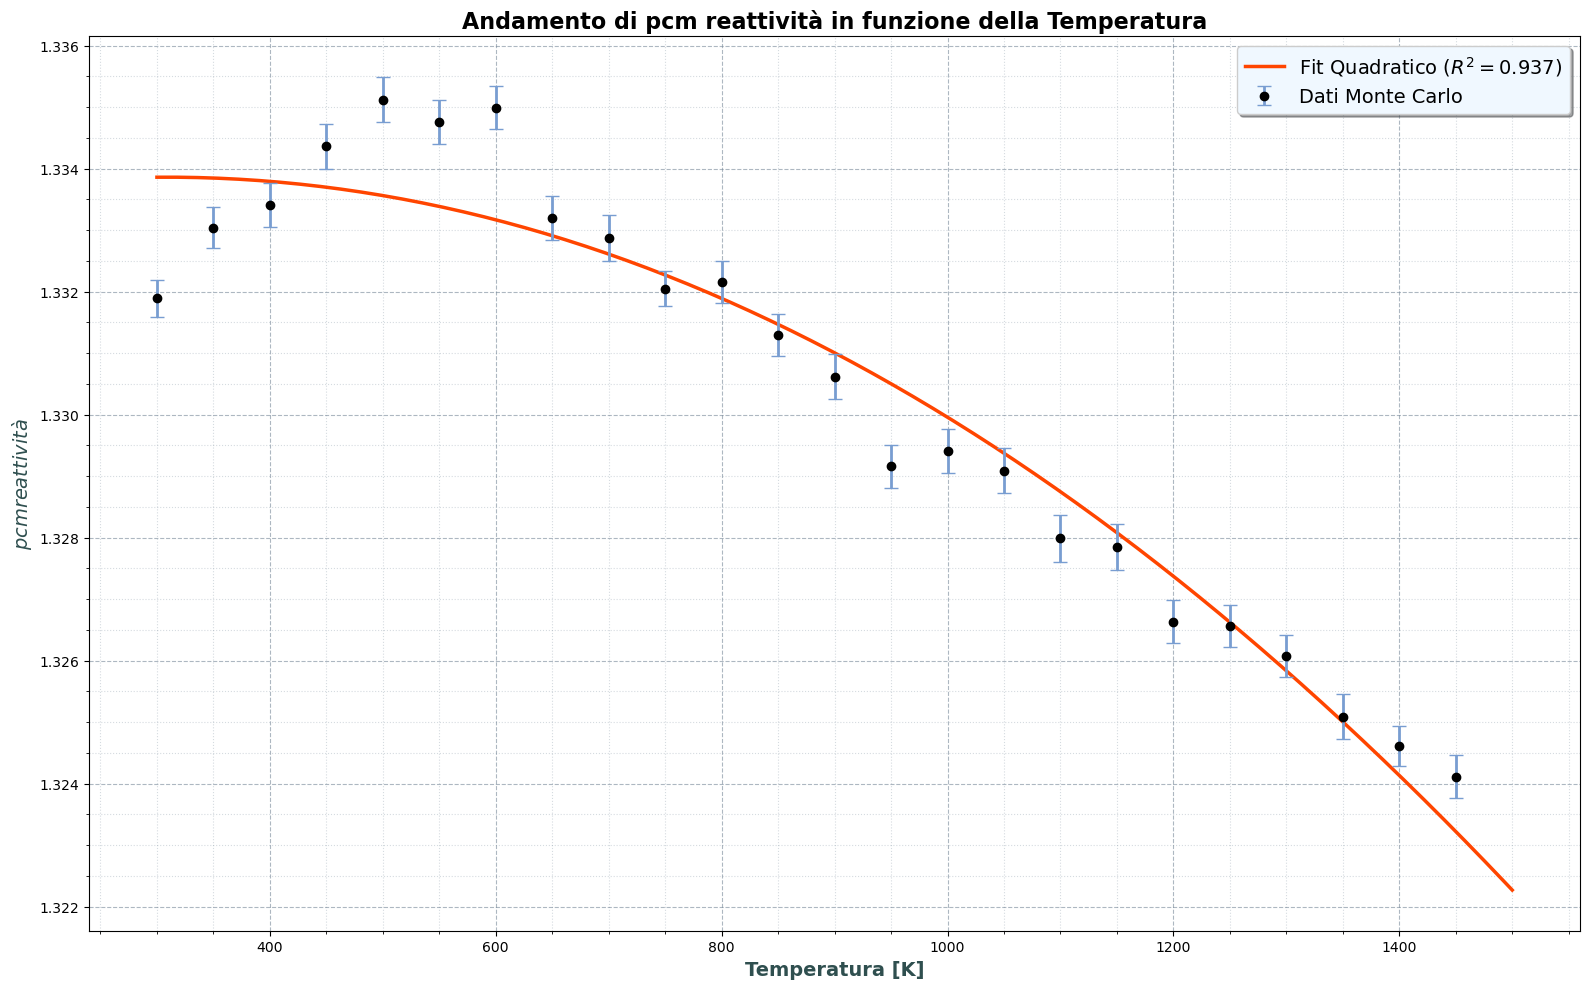

In [ ]:
# --- 1. LETTURA DEL FILE result.txt ---
filename = "result.txt"
temps = []
k_effs = []
stds = []

# Parser robusto: salta l'header e legge solo le righe che iniziano con numeri
with open(filename, 'r') as f:
    for line in f:
        line = line.strip()
        if not line: continue
        # Se il primo carattere è un numero, assumiamo sia una riga dati
        if line[0].isdigit():
            parts = line.split()
            if len(parts) >= 3:
                temps.append(float(parts[0]))
                k_effs.append(float(parts[1]))
                stds.append(float(parts[2]))

T_data = np.array(temps)
k_data = np.array(k_effs)
err_data = np.array(stds)

pcm = (k_data - 1)/(10e-5*k_data)

# --- 2. FIT QUADRATICO ---
# Modello: k(T) = a*T^2 + b*T + c
coeffs = np.polyfit(T_data, k_data , 2)
poly_fit = np.poly1d(coeffs)

# Generazione dati per la curva del fit (più fitta per morbidezza)
T_fit = np.linspace(min(T_data), max(T_data) + 50, 200)
pcm_fit = poly_fit(T_fit)

# Calcolo R^2 per valutare la bontà del fit
r2 = r2_score(k_data, poly_fit(T_data))

print(f"Fit Quadratico: k(T) = {coeffs[0]:.2e} * T^2 + {coeffs[1]:.2e} * T + {coeffs[2]:.5f}")
print(f"R^2: {r2:.5f}")

# --- 3. PLOTTING (Stile Unificato) ---
fig, ax = plt.subplots(figsize=(16, 10))

# Plot dei dati con barre d'errore
ax.errorbar(T_data, k_data, yerr=err_data, 
            fmt='o',                  # Punti senza linea di congiunzione
            color='#000000',          # Colore punti
            ecolor='#789DD1',         # Colore barre errore
            elinewidth=2,             # Spessore barre
            capsize=5,                # Cappuccetto barre
            label='Dati Monte Carlo',
            zorder=5)

# Plot della curva di fit
ax.plot(T_fit, pcm_fit, 
        color='#FF4500',          # Arancione scuro per contrasto
        linestyle='-', 
        linewidth=2.5, 
        label=f'Fit Quadratico ($R^2={r2:.3f}$)',
        zorder=4)

# Formattazione Stile
font_labels = {'fontsize': 14, 'fontweight': 'bold', 'color': '#2F4F4F'}

ax.set_xlabel('Temperatura [K]', **font_labels)
ax.set_ylabel('$pcm reattività$', **font_labels)
ax.set_title('Andamento di pcm reattività in funzione della Temperatura', fontsize=16, fontweight='bold')

# Griglia
ax.minorticks_on()
ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')

# Legenda
ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=14, facecolor='#F0F8FF')

plt.tight_layout()
plt.show()